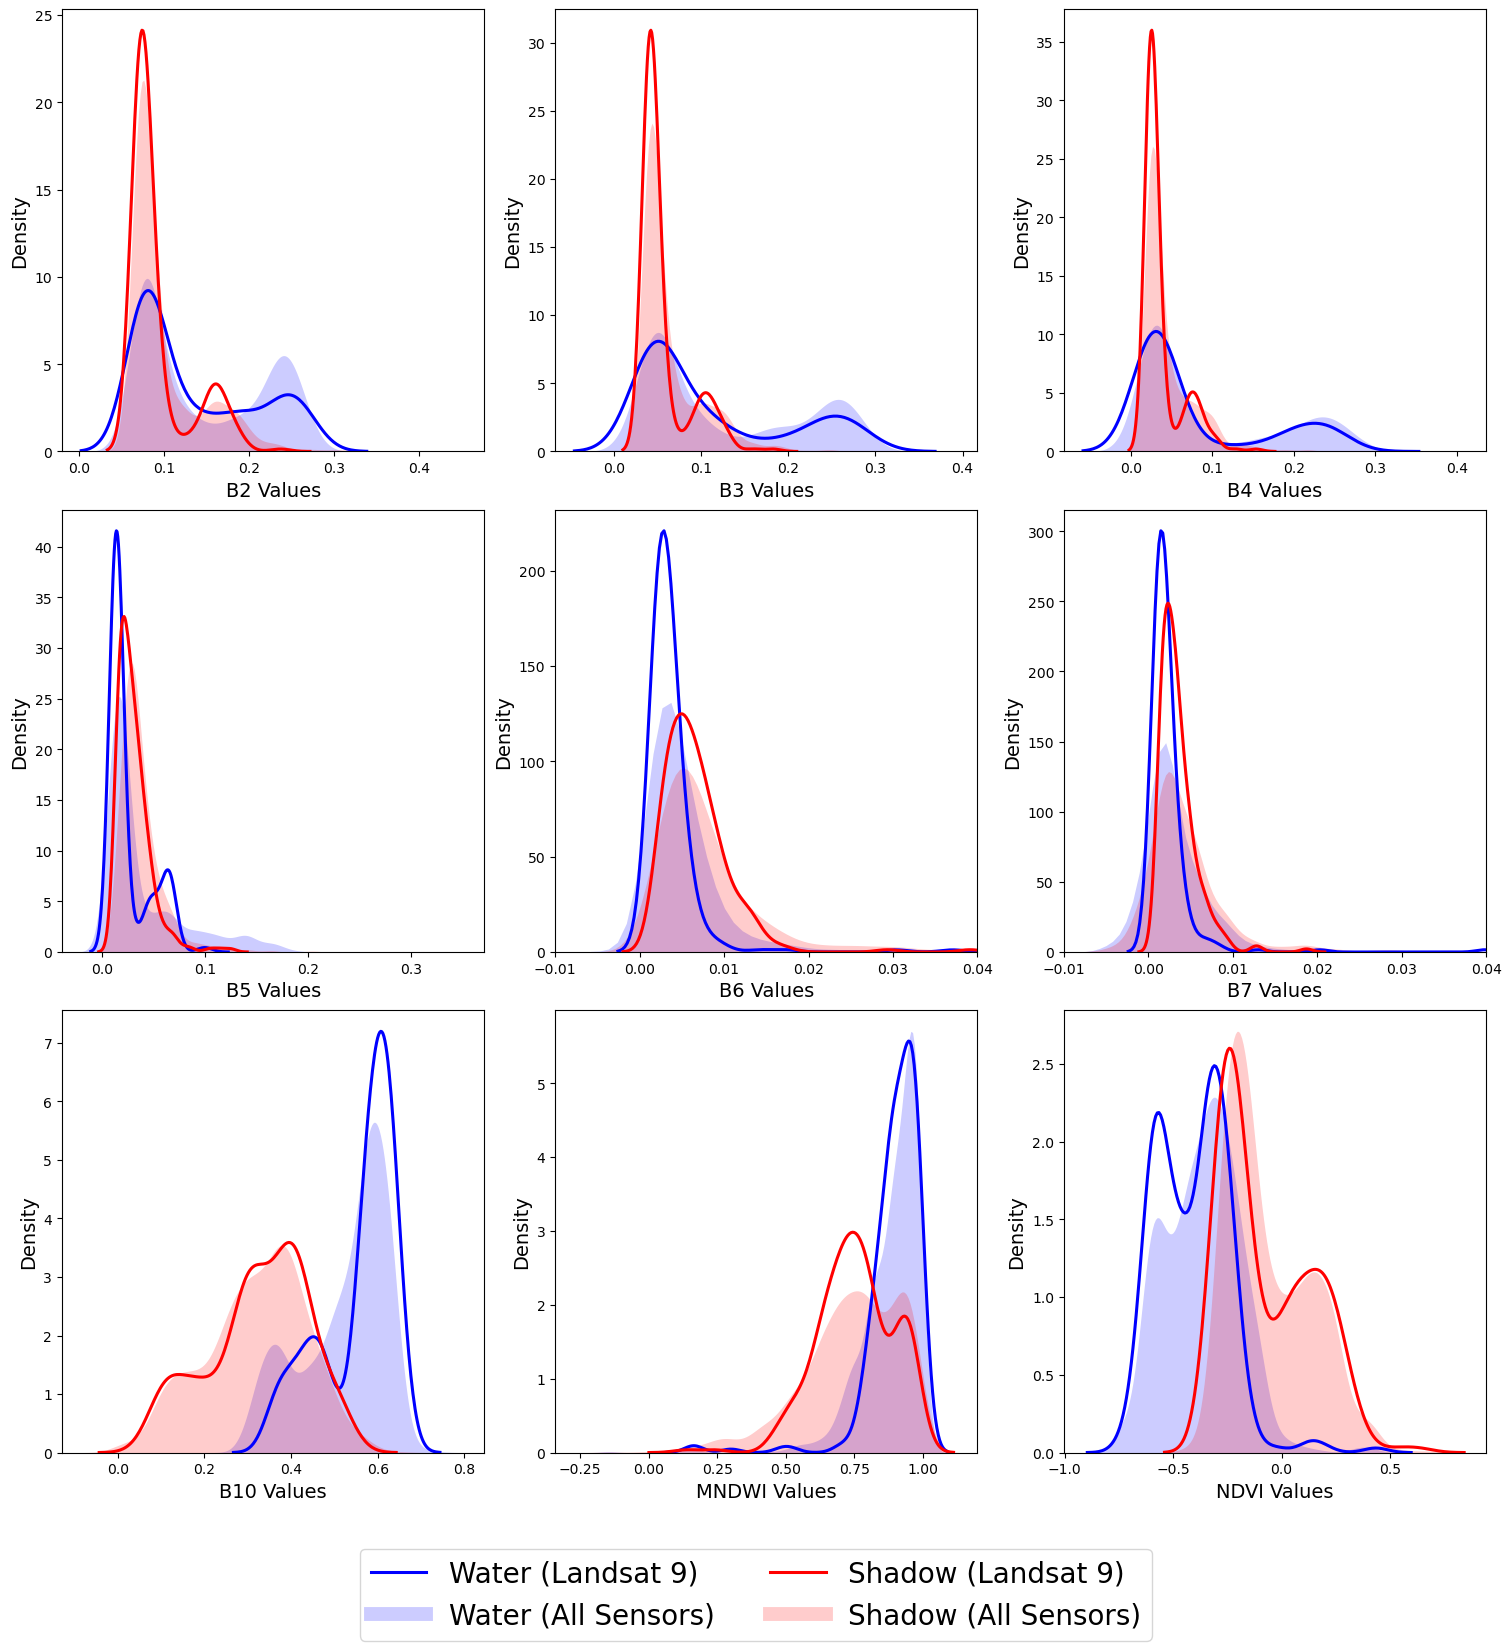

Saved to: C:\Users\tomos\OneDrive - Ulster University\GlacialExtractionData\scripts\figure_scripts\Figure8\Figure8.png


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os

base_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
file_path = os.path.join(base_dir, "KDE_distributions.csv")
save_path = os.path.join(base_dir, "Figure8.png")

df = pd.read_csv(file_path)
df = df[df['Class'].isin(['Water', 'Shadow'])]

class_order = ['Water', 'Shadow']
class_colors = {
    "Water": "blue",
    "Shadow": "red"
}
class_name_map = {
    'Water': 'Water',
    'Shadow': 'Shadow'
}

bands = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B10_normalized', 'MNDWI', 'NDVI']
bands = [b for b in bands if b in df.columns]
plot_labels = ['B10' if b == 'B10_normalized' else b for b in bands]

fig, axes = plt.subplots(3, 3, figsize=(15, 15), constrained_layout=True)
axes = axes.flatten()

for idx, (band, label) in enumerate(zip(bands, plot_labels)):
    ax = axes[idx]
    
    for class_label in class_order:
        color = class_colors[class_label]

        data_all = df[df['Class'] == class_label]
        if not data_all.empty and band in data_all.columns:
            sns.kdeplot(
                data=data_all,
                x=band,
                fill=True,
                color=color,
                alpha=0.2,
                linewidth=0,
                ax=ax
            )

        data_l9 = df[(df['Class'] == class_label) & (df['Sensor'] == "LC09")]
        if not data_l9.empty and band in data_l9.columns:
            sns.kdeplot(
                data=data_l9,
                x=band,
                color=color,
                linestyle="-",
                linewidth=2.2,
                ax=ax
            )

    if band in ['B6', 'B7']:
        ax.set_xlim(-0.01, 0.04)

    ax.set_xlabel(f"{label} Values", fontsize=14)
    ax.set_ylabel("Density", fontsize=14)

for idx in range(len(bands), len(axes)):
    fig.delaxes(axes[idx])

custom_handles = []
custom_labels = []

for class_name in class_order:
    color = class_colors[class_name]
    line_l9 = Line2D([0], [0], color=color, linestyle='-', linewidth=2.2)
    fill_all = Line2D([0], [0], color=color, linestyle='-', linewidth=10, alpha=0.2)
    custom_handles.extend([line_l9, fill_all])
    custom_labels.extend([
        f"{class_name_map[class_name]} (Landsat 9)",
        f"{class_name_map[class_name]} (All Sensors)"
    ])

fig.legend(
    handles=custom_handles,
    labels=custom_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    fontsize=20,
    frameon=True
)

plt.rcParams.update({'font.size': 14})

fig.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

print(f"Saved to: {save_path}")